<a href="https://colab.research.google.com/github/phaniraghava1234/physics_informed_neural_networks/blob/main/Pitch_Plunge_Aeroelasticity_PINN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
project_path = "/content/drive/MyDrive/ColabProjects/physics_informed_neural_networks"

os.makedirs(project_path, exist_ok=True)
os.chdir(project_path)

print("Current working directory:", os.getcwd())

Current working directory: /content/drive/MyDrive/ColabProjects/physics_informed_neural_networks


In [3]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy.integrate import solve_ivp
import time

# ==========================================
# 0. Device Configuration
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")


Training on device: cuda


In [8]:
# ==========================================
# 1. Draw Geometry & System Schematic
# ==========================================
def draw_geometry():
    fig, ax = plt.subplots(figsize=(10, 6))

    # Draw Airfoil
    airfoil = patches.Ellipse((0, 0), width=5, height=0.8, angle=10,
                              edgecolor='black', facecolor='lightgray', lw=2)
    ax.add_patch(airfoil)

    # Elastic Axis (EA)
    ax.plot(0, 0, 'ko', markersize=8)
    ax.text(-0.2, 0.4, 'EA\n(Elastic Axis)', ha='center', fontsize=12, fontweight='bold')

    # Center of Gravity (CG)
    cg_x, cg_y = 0.6, -0.1
    ax.plot(cg_x, cg_y, 'ro', markersize=8)
    ax.text(cg_x + 0.2, cg_y - 0.2, 'CG\n(Static Unbalance $S_\\alpha$)', color='red', fontsize=12)

    # Plunge Spring (K_h)
    ax.plot([0, 0], [0, 2], 'k-', lw=3)
    ax.text(-0.7, 1.2, '$K_h$\n(Plunge)', fontsize=14)

    # Torsional Spring (K_alpha)
    arc = patches.Arc((0, 0), 1.5, 1.5, angle=0, theta1=30, theta2=150, color='blue', lw=3)
    ax.add_patch(arc)
    ax.text(-1.5, 0.8, '$K_\\alpha$\n(Pitch)', color='blue', fontsize=14)

    # Flow direction
    ax.arrow(-3.5, 0, 1.5, 0, head_width=0.15, head_length=0.3, fc='black', ec='black')
    ax.text(-3.2, 0.2, 'Freestream $U_\\infty$', fontsize=12)

    ax.set_xlim(-4, 4)
    ax.set_ylim(-1.5, 2.5)
    ax.axis('off')
    ax.set_title('Problem 4: 2-DOF Pitch-Plunge Aeroelastic System', fontsize=16, fontweight='bold')

    plt.savefig('aeroelastic_geometry.png', dpi=300, bbox_inches='tight')
    plt.close()
    print("Geometry diagram saved as 'aeroelastic_geometry.png'")

draw_geometry()

Geometry diagram saved as 'aeroelastic_geometry.png'


In [14]:
# ==========================================
# 2. Exact Analytical Solver (SciPy solve_ivp)
# ==========================================
def exact_aeroelastic(t_eval):
    """
    Computes the exact state-space response of the coupled 2nd-order ODEs.
    M X'' + C X' + K X = 0
    """
    # Mass, Damping, and Stiffness Matrices
    M = np.array([[1.0, 0.2], [0.2, 0.5]])   # [m, S_alpha ; S_alpha, I_alpha]
    C = np.array([[0.1, 0.0], [0.0, 0.1]])   # [c_h, 0 ; 0, c_alpha]
    K = np.array([[4.0, 0.0], [0.0, 5.0]])   # [k_h, 0 ; 0, k_alpha]

    M_inv = np.linalg.inv(M)

    # Convert to 1st-order State-Space: Y = [h, alpha, h_dot, alpha_dot]^T
    A11 = np.zeros((2, 2))
    A12 = np.eye(2)
    A21 = -M_inv @ K
    A22 = -M_inv @ C
    A = np.block([[A11, A12], [A21, A22]])

    def dynamics(t, y):
        return A @ y

    # Initial Conditions: h=1.0, alpha=0.5, h_dot=0, alpha_dot=0
    y0 = [1.0, 0.5, 0.0, 0.0]
    sol = solve_ivp(dynamics, [t_eval[0], t_eval[-1]], y0, t_eval=t_eval)

    return sol.y[0, :], sol.y[1, :] # Return h(t) and alpha(t)

# ==========================================
# 3. Neural Network Architecture (with Fourier Features)
# ==========================================
class PINN(nn.Module):
    def __init__(self, layers):
        super(PINN, self).__init__()
        self.activation = nn.Tanh()

        # FIX: Fourier Feature Embedding to combat Spectral Bias!
        # Maps the 1D time input into a high-frequency space of size layers[1]
        self.B = nn.Parameter(torch.randn(1, layers[1]//2) * 4.0, requires_grad=False)

        # Since Fourier embedding replaces the first input layer, we build from layers[1] onwards
        self.linears = nn.ModuleList([nn.Linear(layers[i], layers[i+1]) for i in range(1, len(layers)-1)])

        for i in range(len(self.linears)):
            nn.init.xavier_normal_(self.linears[i].weight)
            nn.init.zeros_(self.linears[i].bias)

    def forward(self, t):
        # Normalize time from [0, 15] to [-1, 1]
        t_norm = (t - 7.5) / 7.5

        # Apply Fourier Feature Mapping: [cos(wt), sin(wt)]
        w = 2.0 * np.pi * t_norm @ self.B
        ff = torch.cat([torch.cos(w), torch.sin(w)], dim=-1)

        a = ff
        for i in range(len(self.linears) - 1):
            a = self.activation(self.linears[i](a))
        out = self.linears[-1](a)

        # Output is 2-dimensional: Plunge (h) and Pitch (alpha)
        h = out[:, 0:1]
        alpha = out[:, 1:2]
        return h, alpha

# ==========================================
# 4. Physics-Informed Loss Components (Coupled ODEs)
# ==========================================
def compute_loss(model, t_f, t_0, h_0_true, alpha_0_true):
    # --- 1. Physics Loss (PDE Residuals) ---
    t_f.requires_grad_(True)
    h, alpha = model(t_f)

    # First derivatives (Velocities)
    h_t = torch.autograd.grad(h, t_f, grad_outputs=torch.ones_like(h), create_graph=True)[0]
    alpha_t = torch.autograd.grad(alpha, t_f, grad_outputs=torch.ones_like(alpha), create_graph=True)[0]

    # Second derivatives (Accelerations)
    h_tt = torch.autograd.grad(h_t, t_f, grad_outputs=torch.ones_like(h_t), create_graph=True)[0]
    alpha_tt = torch.autograd.grad(alpha_t, t_f, grad_outputs=torch.ones_like(alpha_t), create_graph=True)[0]

    # Coupled ODEs: M X'' + C X' + K X = 0
    # Equation 1: Plunge Dynamics
    f_h = 1.0 * h_tt + 0.2 * alpha_tt + 0.1 * h_t + 4.0 * h
    # Equation 2: Pitch Dynamics
    f_alpha = 0.2 * h_tt + 0.5 * alpha_tt + 0.1 * alpha_t + 5.0 * alpha

    loss_physics = torch.mean(f_h**2) + torch.mean(f_alpha**2)

    # --- 2. Initial Condition Loss ---
    t_0.requires_grad_(True)
    h_pred_0, alpha_pred_0 = model(t_0)

    h_t_pred_0 = torch.autograd.grad(h_pred_0, t_0, grad_outputs=torch.ones_like(h_pred_0), create_graph=True)[0]
    alpha_t_pred_0 = torch.autograd.grad(alpha_pred_0, t_0, grad_outputs=torch.ones_like(alpha_pred_0), create_graph=True)[0]

    # Position ICs: h(0) = 1.0, alpha(0) = 0.5
    loss_ic_pos = torch.mean((h_pred_0 - h_0_true)**2) + torch.mean((alpha_pred_0 - alpha_0_true)**2)
    # Velocity ICs: h'(0) = 0, alpha'(0) = 0
    loss_ic_vel = torch.mean((h_t_pred_0 - 0.0)**2) + torch.mean((alpha_t_pred_0 - 0.0)**2)

    loss_data = loss_ic_pos + loss_ic_vel

    return loss_data, loss_physics

In [15]:
# ==========================================
# 5. Training Setup & Loop
# ==========================================
# Domain: t = 0 to 15 seconds
N_f = 5000 # Increased collocation points for stability
t_f = np.random.uniform(0, 15, (N_f, 1))
t_f_pt = torch.tensor(t_f, dtype=torch.float32, device=device)

# Initial Conditions
t_0_pt = torch.zeros((1, 1), dtype=torch.float32, device=device)
h_0_true = 1.0
alpha_0_true = 0.5

# Model: 1 input (t) -> 4x64 hidden -> 2 outputs (h, alpha)
layers = [1, 64, 64, 64, 64, 2]
model = PINN(layers).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
epochs = 15000

loss_history_total = []
loss_history_physics = []
loss_history_data = []

print("Starting Flight Dynamics PINN Training...")
for epoch in range(epochs):
    optimizer.zero_grad()

    loss_data, loss_physics = compute_loss(model, t_f_pt, t_0_pt, h_0_true, alpha_0_true)

    # FIX: Massive penalty weight on IC Data ensures the wave propagates properly
    # and doesn't average out to zero to falsely minimize physics loss
    loss = 100.0 * loss_data + loss_physics

    loss.backward()
    optimizer.step()

    # Learning rate scheduler for long-time integration
    if epoch in [5000, 10000, 13000]:
        for g in optimizer.param_groups:
            g['lr'] *= 0.5

    loss_history_total.append(loss.item())
    loss_history_physics.append(loss_physics.item())
    loss_history_data.append(loss_data.item())

    if epoch % 1000 == 0:
        print(f'Epoch: {epoch:05d}, Total Loss: {loss.item():.6f}, Physics: {loss_physics.item():.6f}, IC Data: {loss_data.item():.6f}')

print("Training Complete!")


Starting Flight Dynamics PINN Training...
Epoch: 00000, Total Loss: 197.811707, Physics: 65.618385, IC Data: 1.321933
Epoch: 01000, Total Loss: 0.052030, Physics: 0.051993, IC Data: 0.000000
Epoch: 02000, Total Loss: 0.016786, Physics: 0.016777, IC Data: 0.000000
Epoch: 03000, Total Loss: 0.008101, Physics: 0.005037, IC Data: 0.000031
Epoch: 04000, Total Loss: 0.000849, Physics: 0.000849, IC Data: 0.000000
Epoch: 05000, Total Loss: 0.013101, Physics: 0.000712, IC Data: 0.000124
Epoch: 06000, Total Loss: 0.000250, Physics: 0.000250, IC Data: 0.000000
Epoch: 07000, Total Loss: 0.002602, Physics: 0.000376, IC Data: 0.000022
Epoch: 08000, Total Loss: 0.000150, Physics: 0.000149, IC Data: 0.000000
Epoch: 09000, Total Loss: 0.003011, Physics: 0.000175, IC Data: 0.000028
Epoch: 10000, Total Loss: 0.000278, Physics: 0.000098, IC Data: 0.000002
Epoch: 11000, Total Loss: 0.000072, Physics: 0.000072, IC Data: 0.000000
Epoch: 12000, Total Loss: 0.000237, Physics: 0.000078, IC Data: 0.000002
Epoch:

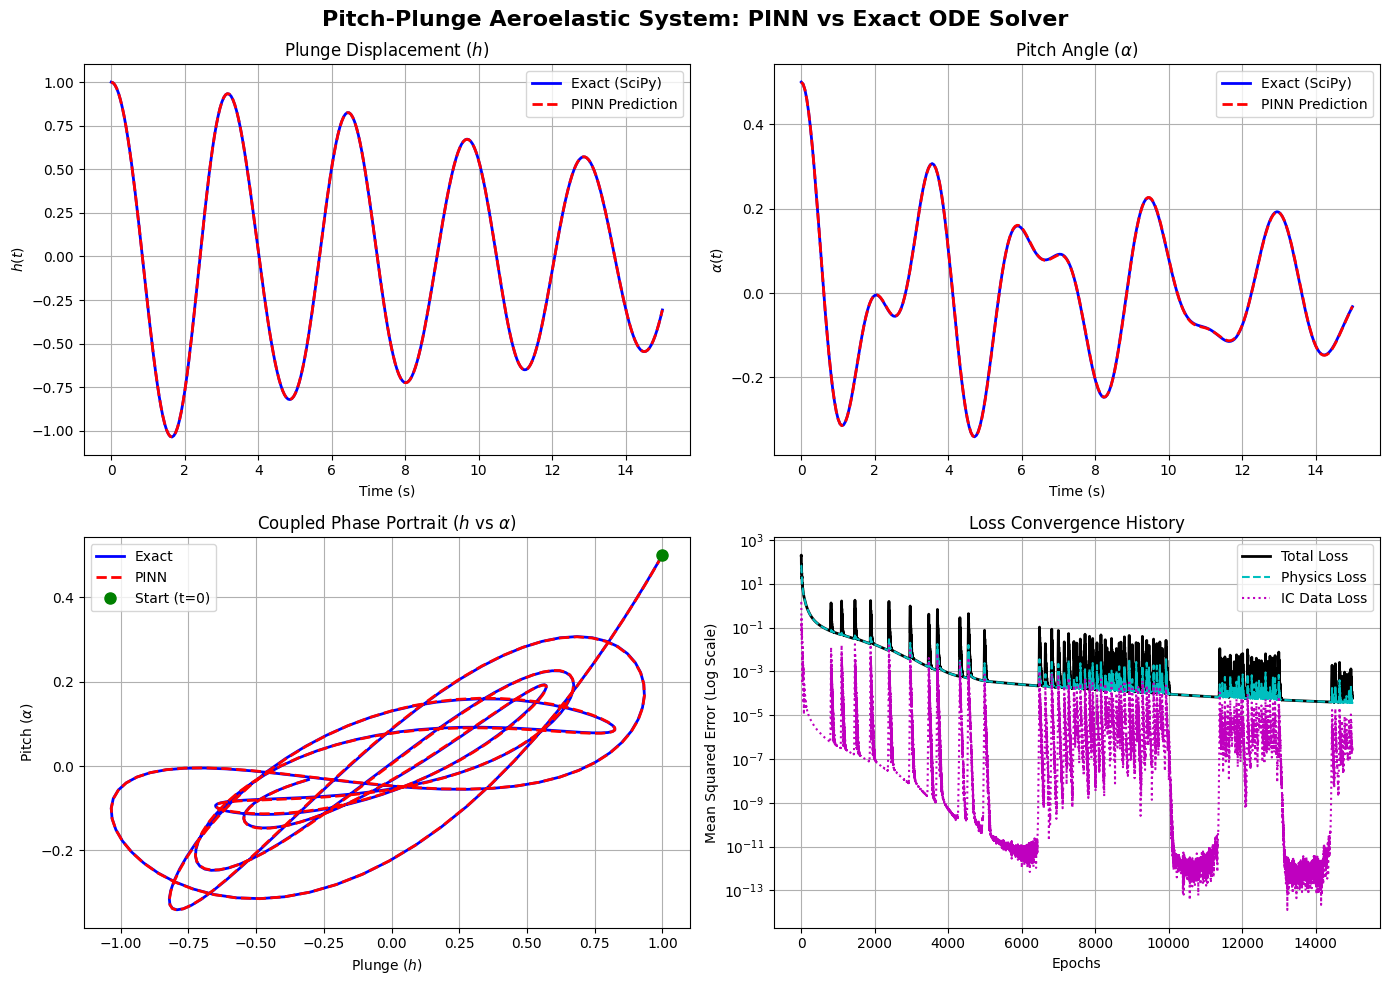

In [16]:
# ==========================================
# 6. Evaluation & Advanced Plotting
# ==========================================
t_eval = np.linspace(0, 15, 300)
t_eval_pt = torch.tensor(t_eval[:, None], dtype=torch.float32, device=device)

# 1. PINN Predictions
with torch.no_grad():
    h_pred, alpha_pred = model(t_eval_pt)
    h_pred = h_pred.cpu().numpy().flatten()
    alpha_pred = alpha_pred.cpu().numpy().flatten()

# 2. Exact SciPy Solutions
h_exact, alpha_exact = exact_aeroelastic(t_eval)

# 3. Create a 2x2 Grid for "More Results"
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Pitch-Plunge Aeroelastic System: PINN vs Exact ODE Solver', fontsize=16, fontweight='bold')

# Top Left: Plunge vs Time
axs[0, 0].plot(t_eval, h_exact, 'b-', label='Exact (SciPy)', lw=2)
axs[0, 0].plot(t_eval, h_pred, 'r--', label='PINN Prediction', lw=2)
axs[0, 0].set_title('Plunge Displacement ($h$)')
axs[0, 0].set_xlabel('Time (s)')
axs[0, 0].set_ylabel('$h(t)$')
axs[0, 0].grid(True); axs[0, 0].legend()

# Top Right: Pitch vs Time
axs[0, 1].plot(t_eval, alpha_exact, 'b-', label='Exact (SciPy)', lw=2)
axs[0, 1].plot(t_eval, alpha_pred, 'r--', label='PINN Prediction', lw=2)
axs[0, 1].set_title('Pitch Angle ($\\alpha$)')
axs[0, 1].set_xlabel('Time (s)')
axs[0, 1].set_ylabel('$\\alpha(t)$')
axs[0, 1].grid(True); axs[0, 1].legend()

# Bottom Left: Phase Portrait
axs[1, 0].plot(h_exact, alpha_exact, 'b-', label='Exact', lw=2)
axs[1, 0].plot(h_pred, alpha_pred, 'r--', label='PINN', lw=2)
axs[1, 0].plot(h_exact[0], alpha_exact[0], 'go', markersize=8, label='Start (t=0)')
axs[1, 0].set_title('Coupled Phase Portrait ($h$ vs $\\alpha$)')
axs[1, 0].set_xlabel('Plunge ($h$)')
axs[1, 0].set_ylabel('Pitch ($\\alpha$)')
axs[1, 0].grid(True); axs[1, 0].legend()

# Bottom Right: Training Loss History
axs[1, 1].plot(loss_history_total, 'k-', label='Total Loss', lw=2)
axs[1, 1].plot(loss_history_physics, 'c--', label='Physics Loss')
axs[1, 1].plot(loss_history_data, 'm:', label='IC Data Loss')
axs[1, 1].set_yscale('log')
axs[1, 1].set_title('Loss Convergence History')
axs[1, 1].set_xlabel('Epochs')
axs[1, 1].set_ylabel('Mean Squared Error (Log Scale)')
axs[1, 1].grid(True); axs[1, 1].legend()

plt.tight_layout()
plt.savefig('aeroelastic_results.png', dpi=300, bbox_inches='tight')
plt.show()